In [2]:
import sys
import os
import glob
import aubio
import numpy as np
from matplotlib import pyplot as plt
from PIL import Image
from scipy import ndimage

print(sys.path)

['/home/gabriel/git/rizhom/env/lib/python36.zip', '/home/gabriel/git/rizhom/env/lib/python3.6', '/home/gabriel/git/rizhom/env/lib/python3.6/lib-dynload', '/usr/lib/python3.6', '', '/home/gabriel/git/rizhom/env/local/lib/python3.6/site-packages', '/home/gabriel/git/rizhom/env/lib/python3.6/site-packages', '/home/gabriel/git/rizhom/env/local/lib/python3.6/site-packages/IPython/extensions', '/home/gabriel/.ipython']


In [25]:
data_path = "../data"
paths = sorted(glob.glob("../data/rec_1/*.jpg"))
data = None
for i, file in enumerate(paths):
    im = np.array(Image.open(file)).astype(np.int16)[:,:,1]
    if data is None:
        data = np.zeros([len(paths) - 1, im.shape[0], im.shape[1]])
        im0 = im
        continue
    data[i-1,:,:] = np.sqrt((im.astype("float") - im0.astype("float")) ** 2)
    #print(i, np.min(data[i-1]), np.max(data[i-1]))
data.shape

1 0.0 245.0
2 0.0 246.0
3 0.0 249.0
4 0.0 255.0
5 0.0 242.0
6 0.0 248.0
7 0.0 255.0
8 0.0 248.0
9 0.0 242.0
10 0.0 245.0
11 0.0 242.0
12 0.0 243.0
13 0.0 239.0
14 0.0 239.0
15 0.0 245.0
16 0.0 248.0
17 0.0 247.0
18 0.0 247.0
19 0.0 252.0
20 0.0 247.0
21 0.0 247.0
22 0.0 248.0
23 0.0 247.0
24 0.0 247.0
25 0.0 247.0
26 0.0 247.0
27 0.0 247.0
28 0.0 249.0
29 0.0 249.0
30 0.0 249.0
31 0.0 249.0
32 0.0 249.0
33 0.0 249.0
34 0.0 254.0
35 0.0 254.0
36 0.0 254.0
37 0.0 254.0
38 0.0 254.0
39 0.0 243.0
40 0.0 247.0
41 0.0 254.0
42 0.0 254.0
43 0.0 254.0
44 0.0 254.0
45 0.0 254.0
46 0.0 255.0
47 0.0 254.0
48 0.0 254.0
49 0.0 254.0
50 0.0 254.0
51 0.0 253.0
52 0.0 254.0
53 0.0 254.0
54 0.0 254.0
55 0.0 254.0
56 0.0 254.0
57 0.0 254.0
58 0.0 254.0
59 0.0 254.0
60 0.0 254.0
61 0.0 254.0
62 0.0 254.0
63 0.0 254.0
64 0.0 254.0
65 0.0 254.0
66 0.0 254.0
67 0.0 254.0
68 0.0 254.0
69 0.0 254.0
70 0.0 254.0
71 0.0 254.0
72 0.0 254.0
73 0.0 254.0
74 0.0 254.0
75 0.0 255.0
76 0.0 255.0
77 0.0 255.0
78 0.0 2

(179, 1080, 1920)

In [31]:
x_off = (200, 800)
y_off = (200, 700)
pixel_cos = []
pix_imgs = data[::3]
len(pix_imgs)
for idx, img in enumerate(pix_imgs):
    conv = ndimage.convolve(img[x_off[0]:x_off[1],y_off[0]:y_off[1]], kernel, mode='constant')
    pixel_cos.append(np.array(np.unravel_index(np.argmax(conv), conv.shape)) + [x_off[0], y_off[0]])
    print("Pixel Nr:", idx, ". Co:", pixel_cos[-1])

Pixel Nr: 0 . Co: [305 545]
Pixel Nr: 1 . Co: [309 527]
Pixel Nr: 2 . Co: [317 497]
Pixel Nr: 3 . Co: [329 477]
Pixel Nr: 4 . Co: [337 453]
Pixel Nr: 5 . Co: [341 448]
Pixel Nr: 6 . Co: [349 433]
Pixel Nr: 7 . Co: [361 385]
Pixel Nr: 8 . Co: [337 392]
Pixel Nr: 9 . Co: [377 336]
Pixel Nr: 10 . Co: [377 340]
Pixel Nr: 11 . Co: [389 344]
Pixel Nr: 12 . Co: [385 341]
Pixel Nr: 13 . Co: [377 349]
Pixel Nr: 14 . Co: [365 353]
Pixel Nr: 15 . Co: [373 357]
Pixel Nr: 16 . Co: [388 361]
Pixel Nr: 17 . Co: [416 341]
Pixel Nr: 18 . Co: [445 329]
Pixel Nr: 19 . Co: [481 321]
Pixel Nr: 20 . Co: [489 321]
Pixel Nr: 21 . Co: [521 309]
Pixel Nr: 22 . Co: [544 305]
Pixel Nr: 23 . Co: [560 305]
Pixel Nr: 24 . Co: [574 305]
Pixel Nr: 25 . Co: [577 297]
Pixel Nr: 26 . Co: [562 301]
Pixel Nr: 27 . Co: [561 305]
Pixel Nr: 28 . Co: [561 301]
Pixel Nr: 29 . Co: [573 299]
Pixel Nr: 30 . Co: [609 341]
Pixel Nr: 31 . Co: [613 353]
Pixel Nr: 32 . Co: [617 369]
Pixel Nr: 33 . Co: [625 385]
Pixel Nr: 34 . Co: [633 

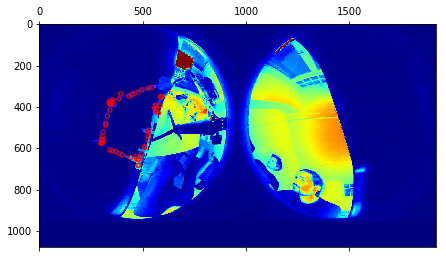

In [33]:
x_off = (200, 800)
y_off = (200, 700)
#plt.matshow(im0[x_off[0]:x_off[1],y_off[0]:y_off[1]], cmap='jet')
plt.matshow(im0, cmap='jet')

ax = plt.gca()
for co in pixel_cos:    
    ax.add_artist(plt.Circle(co[::-1], 10, color='r', fill=False))

In [44]:
def unit_vector(vector):
    """ Returns the unit vector of the vector.  """
    return vector / np.linalg.norm(vector)

def angle_between(v1, v2):
    """ Returns the angle in radians between vectors 'v1' and 'v2'::

            >>> angle_between((1, 0, 0), (0, 1, 0))
            1.5707963267948966
            >>> angle_between((1, 0, 0), (1, 0, 0))
            0.0
            >>> angle_between((1, 0, 0), (-1, 0, 0))
            3.141592653589793
    """
    v1_u = unit_vector(v1)
    v2_u = unit_vector(v2)
    return np.arccos(np.clip(np.dot(v1_u, v2_u), -1.0, 1.0))

In [49]:
polar_cos = []
radius = im0.shape[1]/4
mid_bottom = np.array([radius]*2)
mid_top = np.array([radius, im0.shape[1]/2 + radius])

print(radius, mid_bottom)
for co in pixel_cos:
    if co[1] > im0.shape[1]/2:
        theta = (np.linalg.norm(co - mid_top) / radius) * np.pi / 2 # 0 - 90deg
        phi = angle_between(co - mid_top, np.array([0, 1])) # 0 - 360deg
    else:
        theta = np.pi - (np.linalg.norm(co - mid_bottom) / radius) * np.pi / 2 # 90 - 180deg
        phi = angle_between(co - mid_bottom, np.array([0, 1])) # 0 - 360deg
    polar_cos.append([theta, phi])
print(polar_cos)

480.0 [480. 480.]
[[2.5306787195299125, 1.215160442494137], [2.5612440222744084, 1.3025660408575694], [2.6052831728206916, 1.4668775481036054], [2.6473487941343343, 1.5906612630460617], [2.665357870999142, 1.7574106332263622], [2.6748177620047384, 1.797069688822532], [2.6861397763302763, 1.9152702420331797], [2.6432918868562543, 2.2445116283524458], [2.5921159485401013, 2.1224513093234436], [2.562213617705355, 2.5206865688832076], [2.572809382897301, 2.507297268629788], [2.6060925009628226, 2.551895136411001], [2.5906269941014584, 2.542058436014278], [2.5962536258421594, 2.475286375441511], [2.5809162426814094, 2.40574068478347], [2.6080860637178422, 2.425647816187667], [2.649357151549339, 2.4834649283738814], [2.6408157763767934, 2.7100977029596938], [2.63434578341186, 2.9138266878490335], [2.621256079584308, 3.1353034283370937], [2.6204334775783598, 3.0850492166449763], [2.56613624949401, 2.9062688628675346], [2.531810440637238, 2.7909876309709643], [2.511903557101662, 2.712814626143

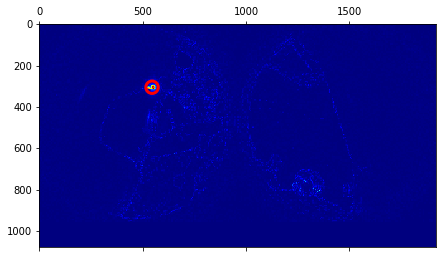

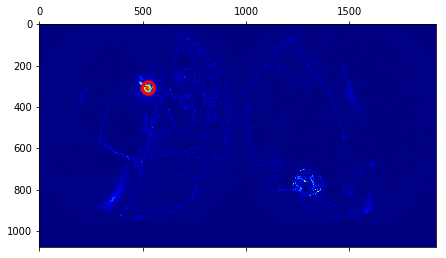

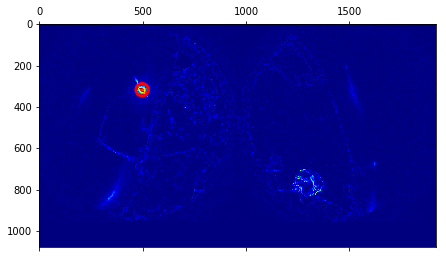

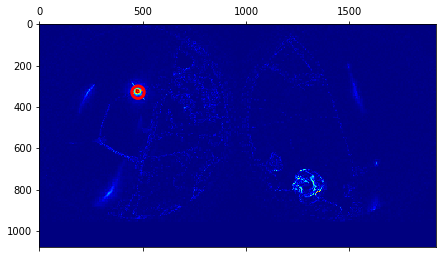

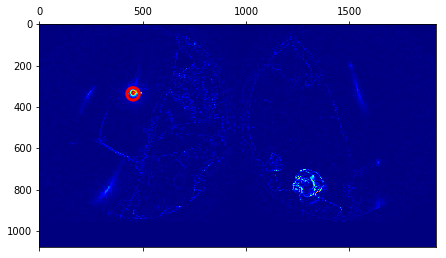

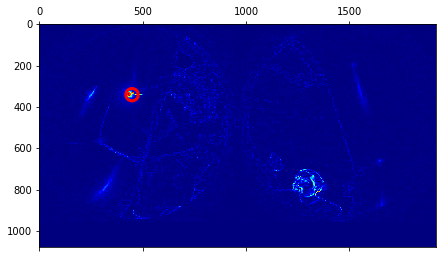

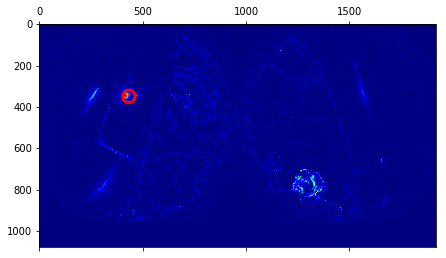

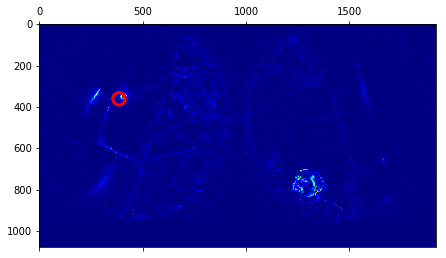

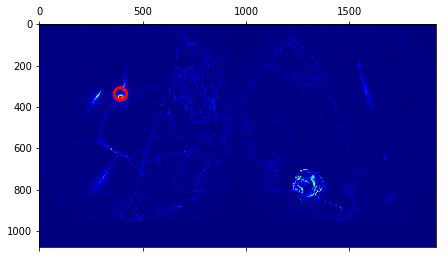

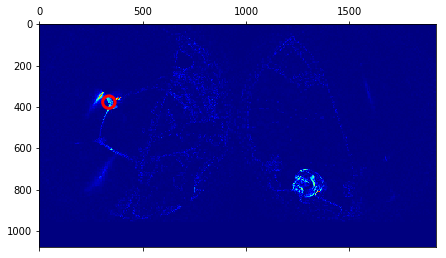

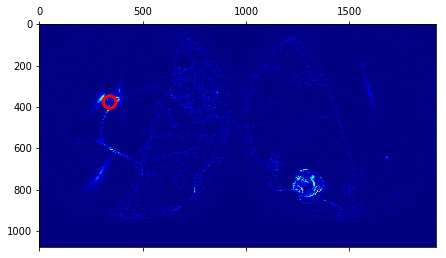

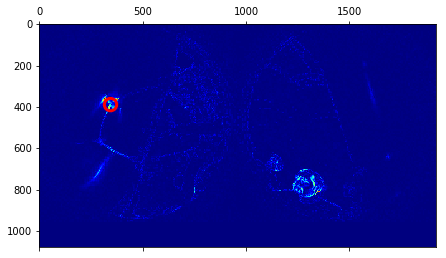

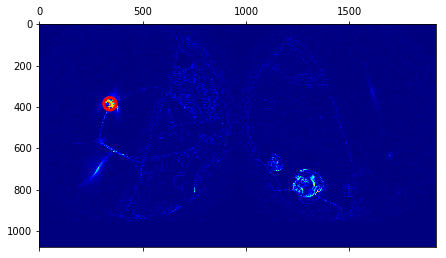

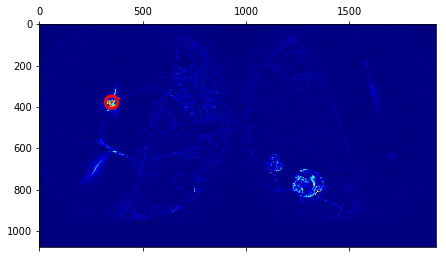

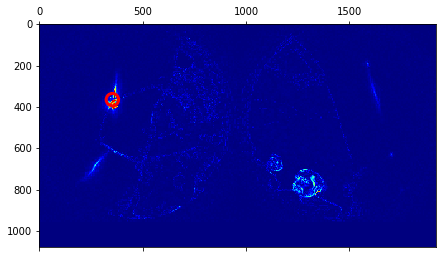

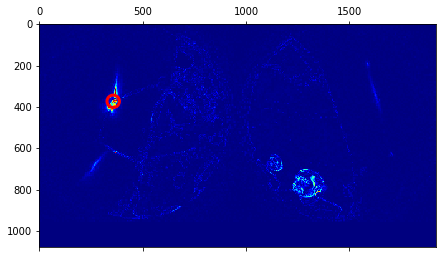

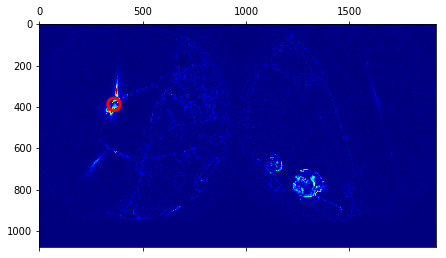

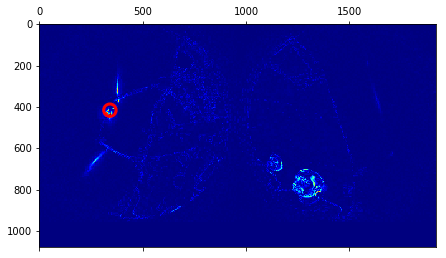

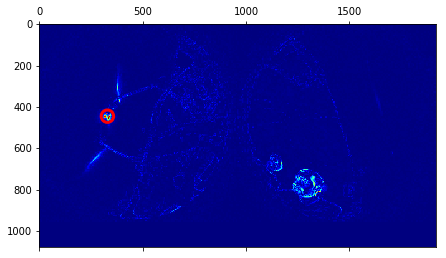

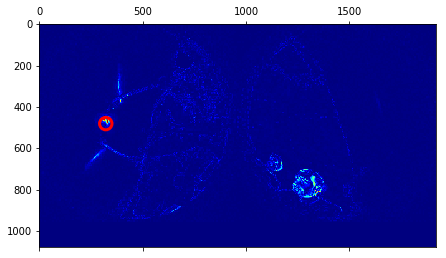

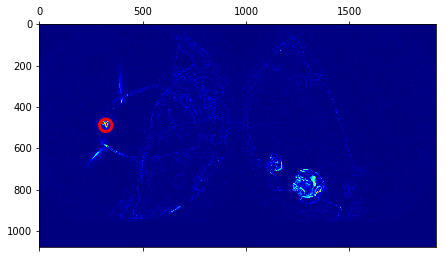

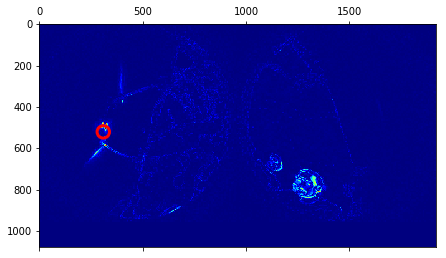

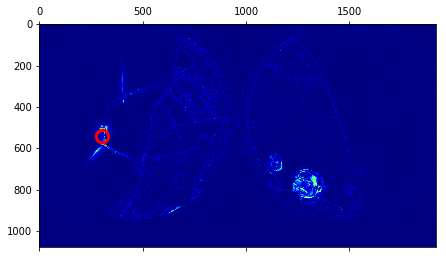

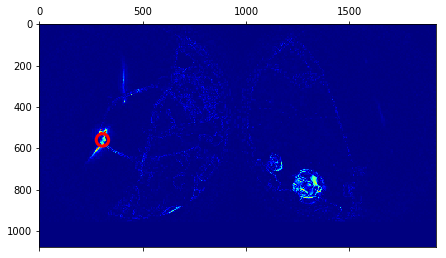

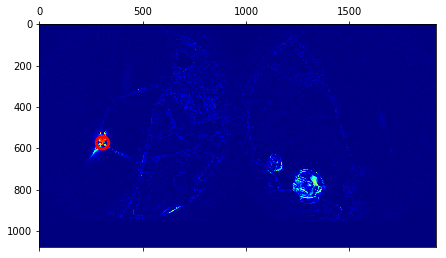

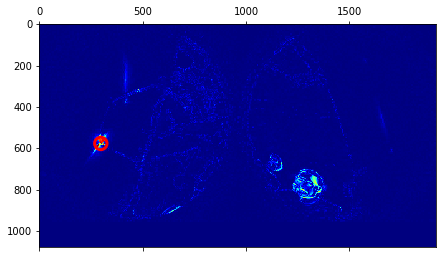

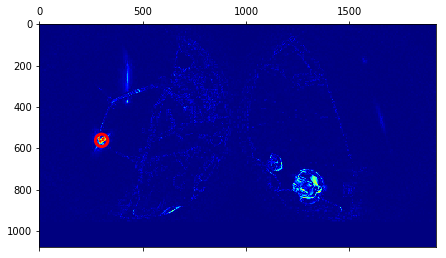

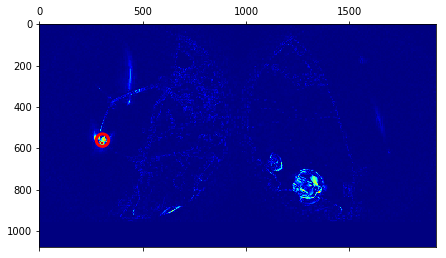

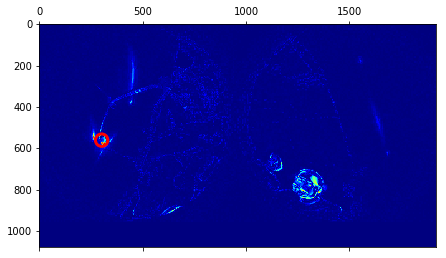

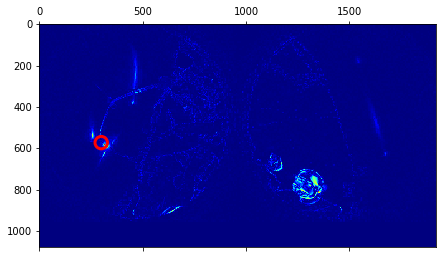

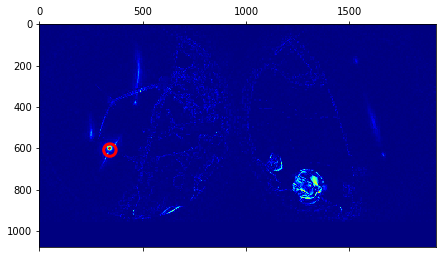

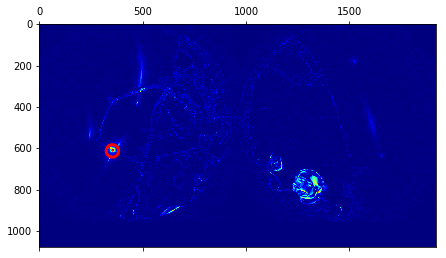

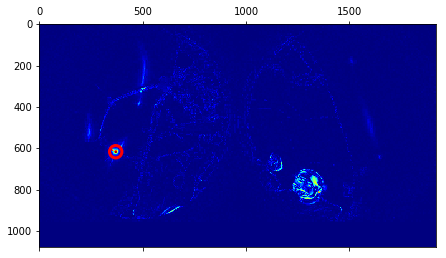

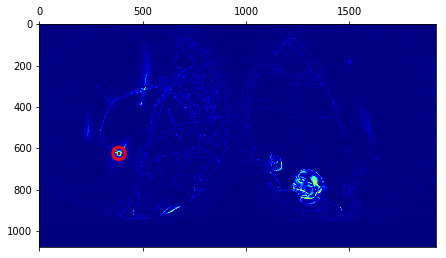

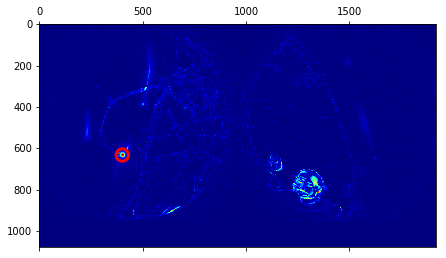

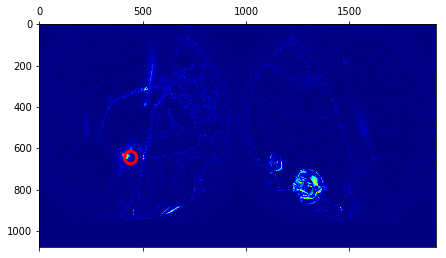

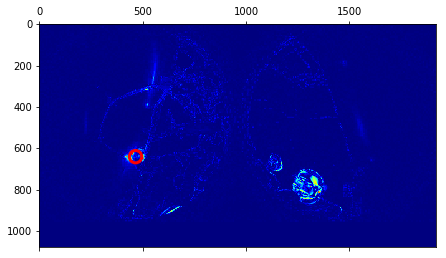

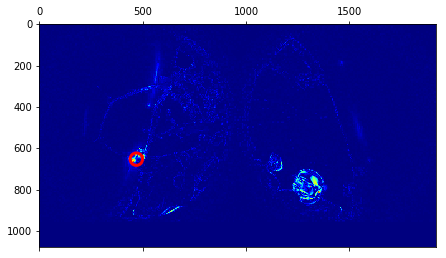

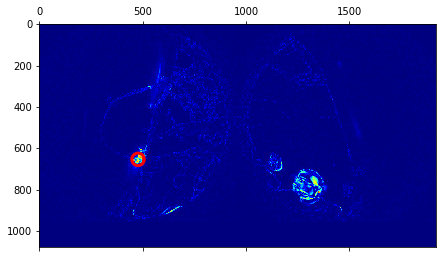

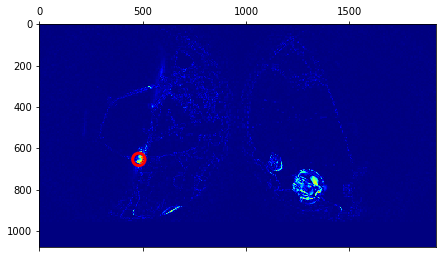

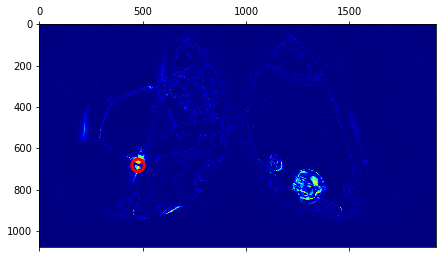

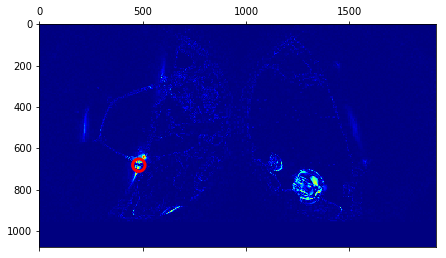

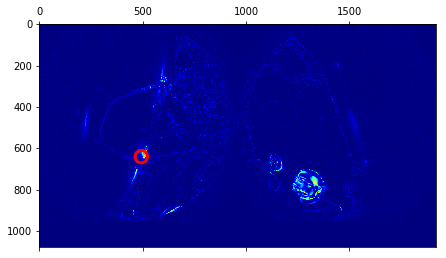

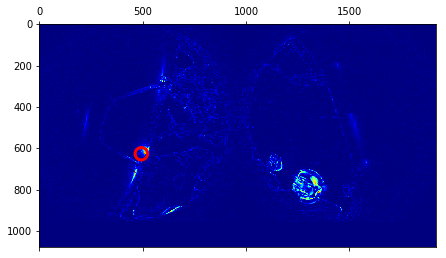

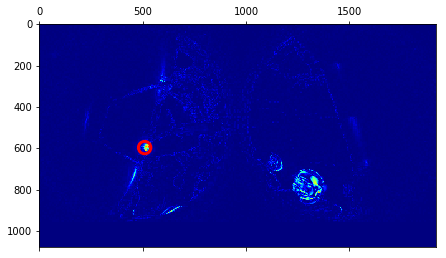

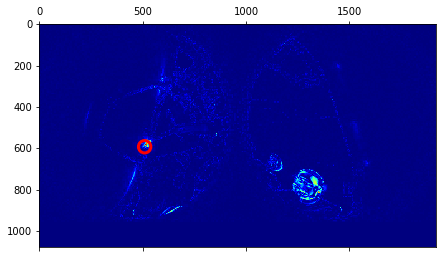

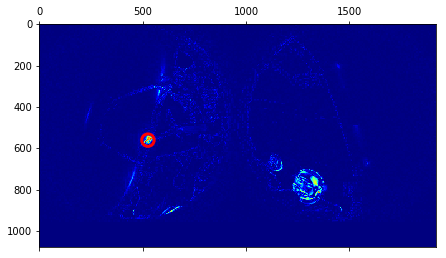

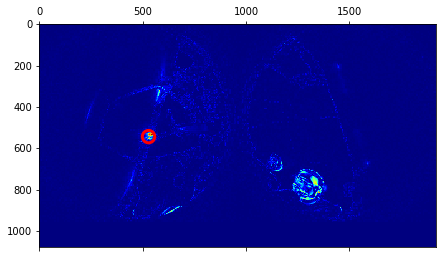

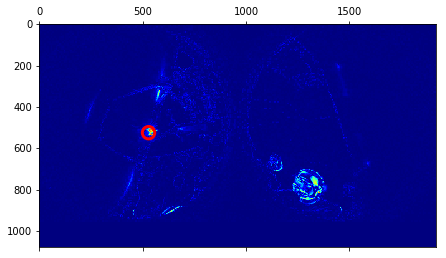

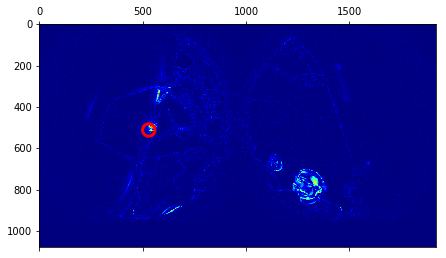

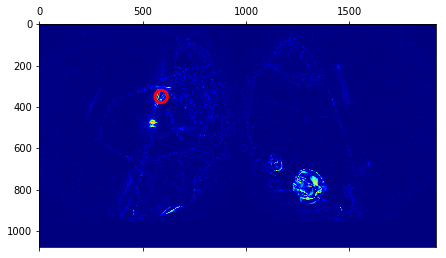

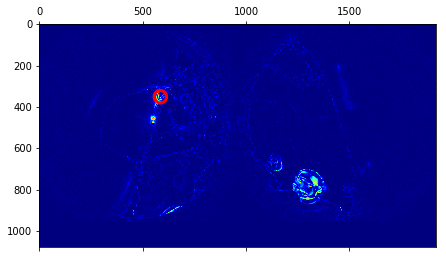

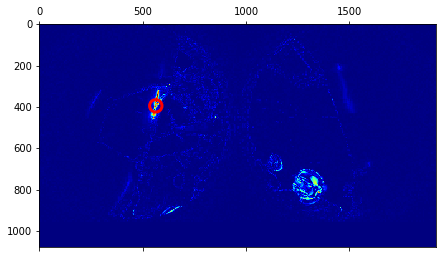

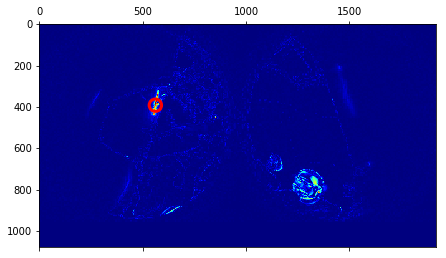

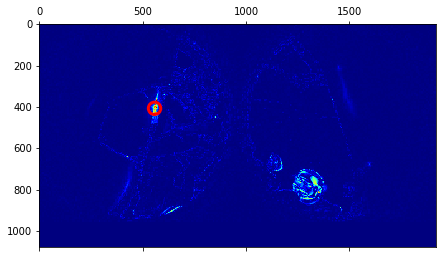

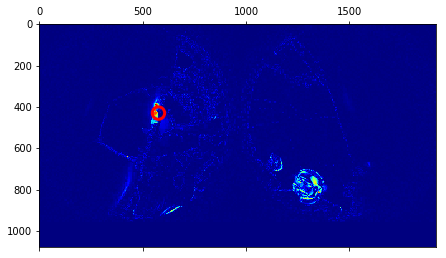

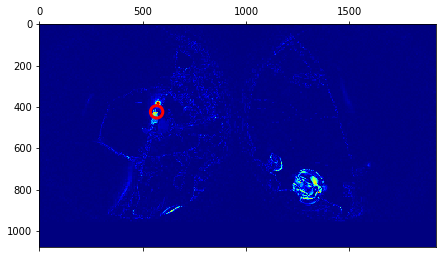

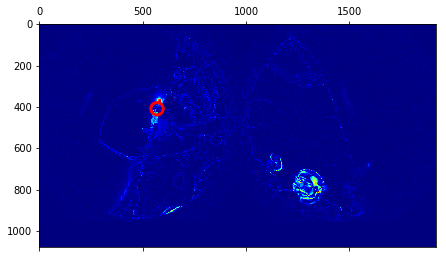

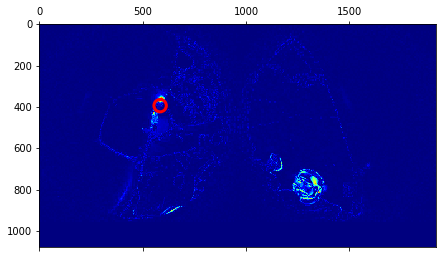

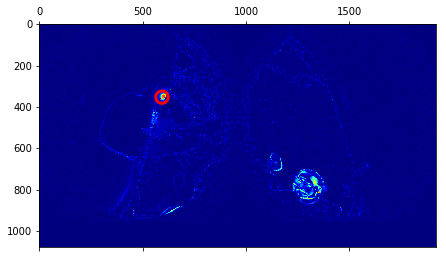

In [38]:
for idx, co in enumerate(pixel_cos):    
    plt.matshow(pix_imgs[idx], cmap='jet')
    ax = plt.gca()
    #ax.set_title("Pixel Nr:", str(idx))
    ax.add_artist(plt.Circle(co[::-1], 30, color='r', fill=False, linewidth=3))